# ==========================================
# CELL 1: IMPORTS & GLOBAL DEPENDENCIES
# ==========================================

In [71]:
# ==========================================
# CELL 1: IMPORTS & DEPENDENCIES
# ==========================================
import heapq
import math
import random
import time
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.path as mpath
from IPython.display import clear_output, display

# ==========================================
# CELL 2: CORE D* LITE ALGORITHM
# ==========================================

In [72]:
# ==========================================
# CELL 2: D* LITE (PARTIAL OBSERVABILITY)
# ==========================================

def approx(a, b, tol=1e-5):
    if a == float('inf') and b == float('inf'): return True
    if a == float('inf') or b == float('inf'): return False
    return abs(a - b) < tol

class Key:
    def __init__(self, k1, k2):
        self.k1, self.k2 = k1, k2
    def __lt__(self, other):
        if approx(self.k1, other.k1): return self.k2 < other.k2
        return self.k1 < other.k1
    def __repr__(self): return f"({self.k1:.2f}, {self.k2:.2f})"

class Node:
    def __init__(self, x, y):
        self.x, self.y = x, y
        self.pos = (x, y)
        self.g = float('inf')
        self.rhs = float('inf')
        self.neighbors = []
        
        # --- GROUND TRUTH (What is actually there) ---
        self.type = 'EMPTY' 
        self.crowd_density = 0 
        
        # --- AGENT'S BELIEF (What the agent thinks is there) ---
        self.perceived_type = 'EMPTY'
        self.perceived_crowd = 0
        self.visited = False # <--- FOG OF WAR ADDED HERE
        
    def __lt__(self, other): return self.pos < other.pos
    def __repr__(self): return f"N{self.pos}"

class DStarLite:
    def __init__(self, start, goals, windows, nodes_dict):
        self.start = start 
        self.goals = goals 
        self.windows = windows 
        self.nodes = nodes_dict
        self.km = 0.0
        self.queue = []
        self.in_queue = {} 
        self.fire_near_main_exits = False
        self.prev_fire_state = False

    def h(self, n):
        dx = abs(n.x - self.start.x)
        dy = abs(n.y - self.start.y)
        return max(dx, dy) 

    def c(self, u, v):
        # The agent now ONLY calculates costs based on 'perceived' conditions
        if u.perceived_type == 'FIRE' or v.perceived_type == 'FIRE': return float('inf')
        if u.perceived_type == 'WALL' or v.perceived_type == 'WALL': return float('inf')
        if u.perceived_type == 'RUBBLE' or v.perceived_type == 'RUBBLE': return float('inf')
        
        cost = 1.414 if (u.x != v.x and u.y != v.y) else 1.0
        
        near_fire = any(n.perceived_type == 'FIRE' for n in v.neighbors)
        if near_fire: cost += 100.0 

        if v.perceived_type == 'SMOKE': cost += 50.0
        
        if v in self.windows: 
            cost += 0.0 if self.fire_near_main_exits else 10.0 

        if v.perceived_type == 'CROWD':
            base_penalty = 10.0
            cost += base_penalty * (v.perceived_crowd ** 2) 
            
            active_exits = [n for n in (self.goals + self.windows) if n.perceived_type != 'RUBBLE']
            if active_exits:
                dist_to_exit = min([math.hypot(v.x - g.x, v.y - g.y) for g in active_exits])
                if dist_to_exit < 2: cost -= 15.0 
                
        return cost

    def calc_key(self, u):
        m = min(u.g, u.rhs)
        return Key(m + self.h(u) + self.km, m)

    def update_vertex(self, u):
        key = self.calc_key(u)
        if not approx(u.g, u.rhs):
            heapq.heappush(self.queue, (key, u))
            self.in_queue[u] = key
        elif u in self.in_queue:
            del self.in_queue[u]

    def compute_shortest_path(self):
        while self.queue:
            k_old, u = self.queue[0]
            k_start = self.calc_key(self.start)
            
            if u not in self.in_queue or (self.in_queue[u].k1 != k_old.k1 or self.in_queue[u].k2 != k_old.k2):
                heapq.heappop(self.queue)
                continue
            
            if k_old < k_start or self.start.rhs > self.start.g:
                heapq.heappop(self.queue)
                if u in self.in_queue: del self.in_queue[u]
                
                k_new = self.calc_key(u)
                if k_old < k_new:
                    heapq.heappush(self.queue, (k_new, u))
                    self.in_queue[u] = k_new
                elif u.g > u.rhs:
                    u.g = u.rhs
                    for s in u.neighbors:
                        if s.perceived_type != 'RUBBLE':
                             s.rhs = min(s.rhs, self.c(s, u) + u.g)
                        self.update_vertex(s)
                else:
                    g_old = u.g
                    u.g = float('inf')
                    for s in u.neighbors + [u]:
                        if approx(s.rhs, self.c(s, u) + g_old):
                             if s.perceived_type != 'RUBBLE' and s not in self.goals and s not in self.windows:
                                s.rhs = float('inf')
                                for sp in s.neighbors:
                                    s.rhs = min(s.rhs, self.c(s, sp) + sp.g)
                             if s.perceived_type == 'RUBBLE':
                                 s.rhs = float('inf')
                        self.update_vertex(s)
            else:
                break

    def initialize(self):
        self.km = 0
        self.queue = []
        self.in_queue = {}
        for n in self.nodes.values():
            n.g = float('inf')
            n.rhs = float('inf')
            
        targets = [t for t in (self.goals + self.windows) if t.perceived_type != 'RUBBLE']
        for target in targets:
            target.rhs = 0
            key = self.calc_key(target)
            heapq.heappush(self.queue, (key, target))
            self.in_queue[target] = key
            
        self.compute_shortest_path()

    def update_map(self, changed_nodes):
        for u in changed_nodes:
            if u.perceived_type == 'FIRE':
                for g in self.goals:
                    if math.hypot(u.x - g.x, u.y - g.y) < 15.0: 
                        self.fire_near_main_exits = True
        
        if self.fire_near_main_exits != self.prev_fire_state:
            self.prev_fire_state = self.fire_near_main_exits
            for w in self.windows:
                self.update_vertex(w)
                for n in w.neighbors:
                    if n.perceived_type != 'RUBBLE':
                        n.rhs = min(n.rhs, self.c(n, w) + w.g)
                        self.update_vertex(n)

        for u in changed_nodes:
            if u.perceived_type == 'RUBBLE' and (u in self.goals or u in self.windows):
                u.g = float('inf')
                u.rhs = float('inf')
                for s in u.neighbors: self.update_vertex(s)
                self.update_vertex(u)
                continue

            for s in u.neighbors + [u]:
                if s.perceived_type != 'RUBBLE':
                    if s not in self.goals and s not in self.windows:
                        s.rhs = float('inf')
                        for sp in s.neighbors: s.rhs = min(s.rhs, self.c(s, sp) + sp.g)
                self.update_vertex(s)
                
        self.compute_shortest_path()

    def move_agent(self):
        if self.start.rhs == float('inf'): return None
        best, min_c = None, float('inf')
        
        for n in self.start.neighbors:
            edge_cost = self.c(self.start, n)
            if edge_cost == float('inf'): continue
            if edge_cost + n.g < min_c:
                min_c = edge_cost + n.g
                best = n
                
        if best and min_c != float('inf'):
            self.km += self.h(best) 
            self.start = best 
            return best
        return None

# ==========================================
# CELL 3: SIMULATION & PHYSICS ENGINE
# ==========================================



In [73]:
# ==========================================
# CELL 3: SIMULATION ENVIRONMENT LOGIC
# ==========================================

class Simulation:
    def __init__(self, size=20):
        self.size = size
        self.grid = {}
        self.nodes_list = []
        self.hidden_hazards = set()
        
        for x in range(size):
            for y in range(size):
                n = Node(x, y)
                self.grid[(x,y)] = n
                self.nodes_list.append(n)
        
        directions = [
            (-1, 0), (1, 0), (0, -1), (0, 1),   
            (-1, -1), (-1, 1), (1, -1), (1, 1)  
        ]
        
        for n in self.nodes_list:
            for dx, dy in directions:
                nx, ny = n.x+dx, n.y+dy
                if (nx, ny) in self.grid:
                    n.neighbors.append(self.grid[(nx, ny)])

        self.start_node = self.grid[(size//2, size//2)]
        self.generate_building_plan()
        
        valid_spawns = [
            n for n in self.nodes_list 
            if n.type == 'EMPTY' and n not in self.goals and n not in self.windows
        ]
        
        self.start_node = random.choice(valid_spawns)
        
        self.crowd_agents = [] 
        num_people = int((size * size) * 0.10) 
        count = 0
        while count < num_people:
            n = self.grid[(random.randint(0, size-1), random.randint(0, size-1))]
            if n.type == 'EMPTY' and n != self.start_node and n not in self.goals:
                n.type = 'CROWD'
                self.crowd_agents.append({'node': n, 'rational': random.random() < 0.7})
                count += 1
        self.compute_flow_field()
        
        for n in self.nodes_list:
            if n.type == 'WALL': n.perceived_type = 'WALL'
            else: n.perceived_type = 'EMPTY'
        for g in self.goals: g.perceived_type = g.type
        for w in self.windows: w.perceived_type = w.type

        self.solver = DStarLite(self.start_node, self.goals, self.windows, self.grid)
        self.solver.initialize()
        
        self.steps = 0
        self.escaped = False
        self.trapped = False
        self.trapped_reason = ""
        self.fire_front = []
        self.panic_mode = False 
        
        self.single_source_fire_mode = random.random() < 0.70
        self.has_ignited = False

    def check_line_of_sight(self, target):
        x0, y0 = self.start_node.x, self.start_node.y
        x1, y1 = target.x, target.y
        
        dist = math.hypot(x1 - x0, y1 - y0)
        if dist > 15.0: return False 
        
        steps = int(dist)
        if steps == 0: return True
        
        for i in range(1, steps):
            t = i / steps
            cx = int(x0 + t * (x1 - x0))
            cy = int(y0 + t * (y1 - y0))
            if self.grid[(cx, cy)].type == 'WALL':
                return False 
        return True

    def clear_obstacles(self):
        for n in self.nodes_list:
            if n.type == 'WALL' or n.type == 'RUBBLE': n.type = 'EMPTY'
        self.goals = []
        self.windows = []

    def generate_building_plan(self):
        self.goals = []
        self.windows = []
        
        for n in self.nodes_list:
            n.type = 'WALL'
            
        def carve_rect(x1, x2, y1, y2):
            for x in range(x1, x2 + 1):
                for y in range(y1, y2 + 1):
                    if (x, y) in self.grid:
                        self.grid[(x, y)].type = 'EMPTY'
                        
        def add_door(x, y):
            if (x, y) in self.grid:
                self.grid[(x, y)].type = 'EMPTY'

        carve_rect(1, 58, 27, 32) 
        carve_rect(12, 17, 1, 58) 
        carve_rect(42, 47, 1, 58) 
        
        carve_rect(2, 10, 34, 44)
        carve_rect(2, 10, 46, 57)
        
        carve_rect(19, 40, 34, 57)
        
        carve_rect(49, 57, 34, 40)
        carve_rect(49, 57, 42, 49)
        carve_rect(49, 57, 51, 57)
        
        carve_rect(2, 10, 2, 25)
        
        carve_rect(19, 28, 2, 25)
        carve_rect(30, 40, 2, 25)
        
        carve_rect(49, 57, 2, 12)
        carve_rect(49, 57, 14, 25)
        
        add_door(11, 39)
        add_door(11, 51)
        add_door(11, 13)
        add_door(6, 26) 
        
        add_door(29, 33) 
        add_door(30, 33)
        add_door(18, 45) 
        add_door(41, 45)
        add_door(24, 26) 
        add_door(35, 26)
        
        add_door(48, 37)
        add_door(48, 45)
        add_door(48, 54)
        add_door(48, 7)
        add_door(48, 19)

        exits = [
            (14, 59), (15, 59), (44, 59), (45, 59), 
            (14, 0), (15, 0), (44, 0), (45, 0),     
            (0, 29), (0, 30), (59, 29), (59, 30)    
        ]
        for ex, ey in exits:
            if (ex, ey) in self.grid:
                self.grid[(ex, ey)].type = 'EMPTY'
                self.goals.append(self.grid[(ex, ey)])

        for i in range(5, 55, 12):
            if self.grid[(2, i)].type == 'EMPTY': 
                self.grid[(0, i)].type = 'EMPTY'      
                self.windows.append(self.grid[(0, i)])
            if self.grid[(57, i)].type == 'EMPTY': 
                self.grid[(59, i)].type = 'EMPTY'     
                self.windows.append(self.grid[(59, i)])
            if self.grid[(i, 2)].type == 'EMPTY': 
                self.grid[(i, 0)].type = 'EMPTY'      
                self.windows.append(self.grid[(i, 0)])
            if self.grid[(i, 57)].type == 'EMPTY': 
                self.grid[(i, 59)].type = 'EMPTY'     
                self.windows.append(self.grid[(i, 59)])

    def check_connectivity(self):
        q = deque([self.start_node])
        visited = {self.start_node}
        found_exit = False
        while q:
            curr = q.popleft()
            if curr in self.goals or curr in self.windows:
                found_exit = True
                break
            for n in curr.neighbors:
                if n.type != 'WALL' and n.type != 'RUBBLE' and n not in visited:
                    visited.add(n)
                    q.append(n)
        return found_exit

    def ignite_and_spread(self):
        updates = []
        
        should_ignite = False
        if not self.has_ignited:
            if random.random() < 0.15: should_ignite = True
        else:
            if not self.single_source_fire_mode and random.random() < 0.05:
                should_ignite = True

        if should_ignite: 
            rx, ry = random.randint(1, self.size-2), random.randint(1, self.size-2)
            s = self.grid[(rx, ry)]
            if s.type == 'EMPTY' and s != self.start_node:
                s.type = 'FIRE'
                self.fire_front.append(s)
                updates.append(s)
                self.has_ignited = True

        new_fire = []
        spread_chance = random.uniform(0.40, 0.70) 
        
        for f in self.fire_front:
            for n in f.neighbors:
                if n.type != 'FIRE' and n.type != 'WALL' and n.type != 'RUBBLE' and n not in self.goals:
                    if random.random() < spread_chance: 
                        n.type = 'FIRE'
                        new_fire.append(n)
                        updates.append(n)
                        self.crowd_agents = [c for c in self.crowd_agents if c['node'] != n]
                    elif random.random() < 0.80 and n.type == 'EMPTY':
                        n.type = 'SMOKE'
                        updates.append(n)
                        
        self.fire_front.extend(new_fire)
        return updates

    def trigger_collapse(self):
        active_exits = [n for n in (self.goals + self.windows) if n.type != 'RUBBLE']
        
        if len(active_exits) > 1 and random.random() < 0.20: 
            victim = random.choice(active_exits)
            
            fire_nearby = False
            if self.fire_front:
                min_dist = float('inf')
                for f in self.fire_front:
                    d = math.hypot(f.x - victim.x, f.y - victim.y)
                    if d < min_dist: min_dist = d
                    if min_dist <= 5: 
                        fire_nearby = True
                        break
            
            crowd_count = sum(1 for n in victim.neighbors if n.type == 'CROWD')
            crowded = crowd_count >= 3 
            
            if (fire_nearby or crowded) and random.random() < 0.3:
                victim.type = 'RUBBLE'
                self.hidden_hazards.add(victim) 
                return True, victim

        return False, None

    def move_crowds(self):
        updates = []
        random.shuffle(self.crowd_agents)
        all_exits = [e for e in (self.goals + self.windows) if e.type != 'RUBBLE']
        
        if self.panic_mode:
            self.compute_flow_field()
        
        for agent in self.crowd_agents:
            curr = agent['node']
            if curr.type == 'FIRE': continue 
            
            valid = [n for n in curr.neighbors if n.type == 'EMPTY' or n in all_exits]
            if not valid: continue

            target = None
            if self.panic_mode:
                if agent['rational'] and all_exits:
                    target = min(valid, key=lambda n: self.flow_field.get(n, float('inf')))
                    if self.flow_field.get(target, float('inf')) == float('inf'):
                        target = random.choice(valid)
                else:
                    target = random.choice(valid) 
            else:
                target = random.choice(valid) if random.random() < 0.3 else None

            if target:
                if target in all_exits:
                    curr.type = 'EMPTY'
                    updates.append(curr)
                    agent['node'] = None 
                elif target.type == 'EMPTY':
                    curr.type = 'EMPTY'
                    target.type = 'CROWD'
                    agent['node'] = target
                    updates.append(curr); updates.append(target)

        self.crowd_agents = [a for a in self.crowd_agents if a['node'] is not None]
        return updates

    def compute_flow_field(self):
        self.flow_field = {n: float('inf') for n in self.nodes_list}
        active_exits = [n for n in (self.goals + self.windows) if n.type != 'RUBBLE']
        
        q = deque(active_exits)
        for e in active_exits:
            self.flow_field[e] = 0
            
        while q:
            curr = q.popleft()
            for n in curr.neighbors:
                if n.type not in ['WALL', 'RUBBLE', 'FIRE'] and self.flow_field[n] == float('inf'):
                    self.flow_field[n] = self.flow_field[curr] + 1
                    q.append(n)

    def step(self):
        has_fire = len(self.fire_front) > 0
        if has_fire: self.panic_mode = True

        if (self.start_node in self.goals or self.start_node in self.windows) and self.start_node.type != 'RUBBLE':
            self.escaped = True
            return

        self.ignite_and_spread()
        self.move_crowds()
        self.trigger_collapse()
        
        for n in self.nodes_list: n.crowd_density = 0
        for agent in self.crowd_agents:
            n = agent['node']
            count = sum(1 for nb in n.neighbors if nb.type == 'CROWD')
            n.crowd_density = count

        perception_updates = []
        for n in self.nodes_list:
            if self.check_line_of_sight(n):
                n.visited = True  # <--- FOG OF WAR ADDED HERE
                
                n.perceived_crowd = n.crowd_density 
                actual_structure = 'EMPTY' if n.type == 'CROWD' else n.type
                
                if n.perceived_type != actual_structure:
                    n.perceived_type = actual_structure
                    perception_updates.append(n)

        if perception_updates: 
            self.solver.update_map(perception_updates)
        
        if self.panic_mode:
            next_n = self.solver.move_agent()
            if next_n: 
                self.start_node = next_n
            else: 
                self.trapped = True
                fire_nearby = any(n.type == 'FIRE' for n in self.start_node.neighbors)
                rubble_nearby = any(n.type == 'RUBBLE' for n in self.start_node.neighbors)
                if fire_nearby: self.trapped_reason = "Surrounded by Fire"
                elif rubble_nearby: self.trapped_reason = "Exit Collapsed (Rubble)"
                else: self.trapped_reason = "No Path Found (Trapped in Room)"

        self.steps += 1

# ==========================================
# CELL 4: HIGH-RES FOG OF WAR VISUALIZATION
# ==========================================

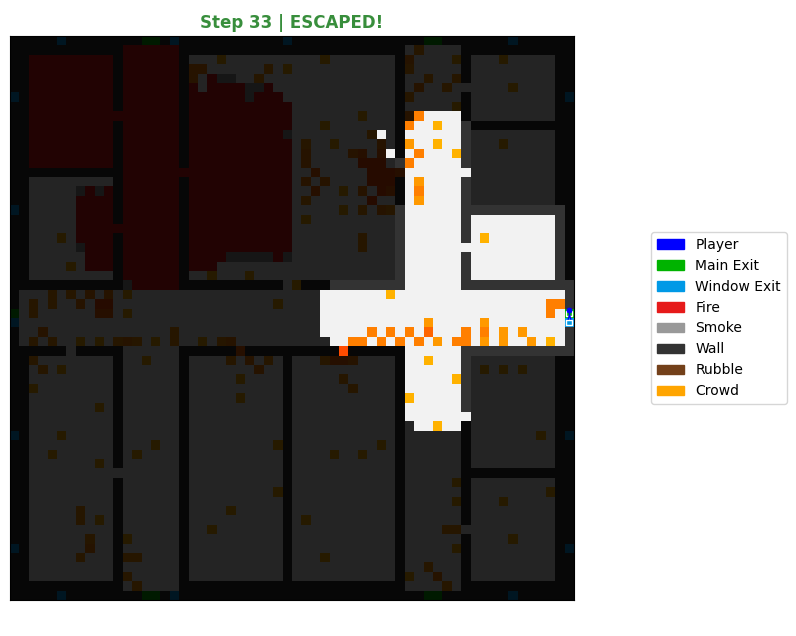

Simulation Complete. Total Steps: 33 | Replanning Events: 23


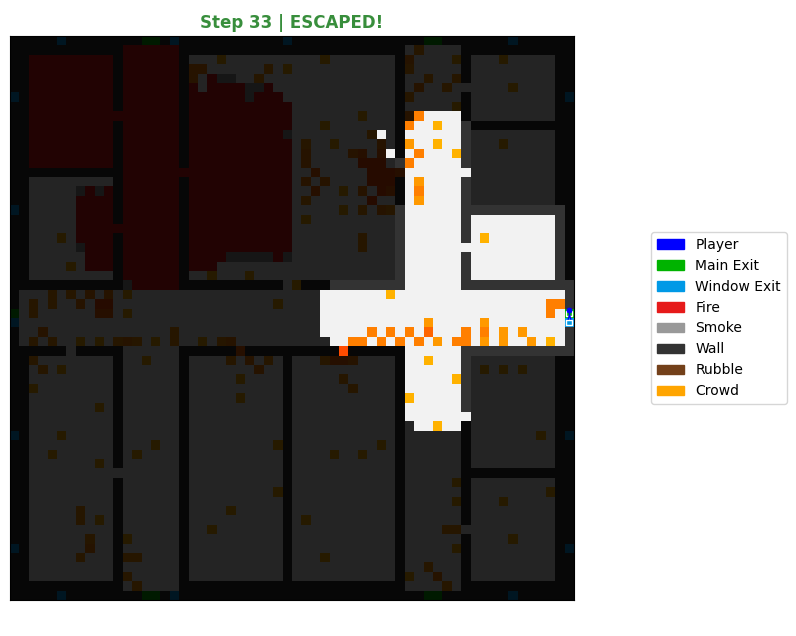

In [74]:
# ==========================================
# CELL 4: OPTIMIZED HIGH-RES VISUALIZATION
# ==========================================

def create_stick_figure_marker():
    verts = [
        (0.0, 0.5), (0.0, 0.5), (0.0, -0.2), 
        (-0.3, 0.2), (0.3, 0.2), 
        (0.0, -0.2), (-0.2, -0.8), 
        (0.0, -0.2), (0.2, -0.8), 
    ]
    codes = [
        mpath.Path.MOVETO, mpath.Path.MOVETO, mpath.Path.LINETO, 
        mpath.Path.MOVETO, mpath.Path.LINETO, 
        mpath.Path.MOVETO, mpath.Path.LINETO, 
        mpath.Path.MOVETO, mpath.Path.LINETO, 
    ]
    return mpath.Path(verts, codes)

def run_simulation():
    sim = Simulation(size=60)
    
    fig = plt.figure(figsize=(10, 8))
    gs = fig.add_gridspec(1, 2, width_ratios=[4, 1])
    ax = fig.add_subplot(gs[0])
    ax_legend = fig.add_subplot(gs[1])
    
    C_WALL = (0.2, 0.2, 0.2)       
    C_FLOOR = (0.95, 0.95, 0.95)   
    C_FIRE = (0.9, 0.1, 0.1)       
    C_SMOKE = (0.6, 0.6, 0.6)      
    C_RUBBLE = (0.45, 0.25, 0.1)  
    C_GOAL = (0.0, 0.7, 0.0)       
    C_WINDOW = (0.0, 0.6, 0.9)     
    
    stick_marker = create_stick_figure_marker()
    
    patches = [
        mpatches.Patch(color='blue', label='Player'),
        mpatches.Patch(color=C_GOAL, label='Main Exit'),
        mpatches.Patch(color=C_WINDOW, label='Window Exit'),
        mpatches.Patch(color=C_FIRE, label='Fire'),
        mpatches.Patch(color=C_SMOKE, label='Smoke'),
        mpatches.Patch(color=C_WALL, label='Wall'),
        mpatches.Patch(color=C_RUBBLE, label='Rubble'),
        mpatches.Patch(color='orange', label='Crowd')
    ]

    rgb_grid = [[C_FLOOR for _ in range(sim.size)] for _ in range(sim.size)]
    img_plot = ax.imshow(rgb_grid, origin='lower', interpolation='nearest')
    
    agent_head = ax.scatter([], [], marker='o', s=10, color='blue', zorder=10) 
    agent_body = ax.scatter([], [], marker=stick_marker, s=80, color='blue', linewidth=1, zorder=10) 
    
    exit_markers = ax.scatter([], [], marker='s', s=15, facecolors='none', edgecolors='white', linewidth=1)
    
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax_legend.axis('off')
    ax_legend.legend(handles=patches, loc='center left', fontsize=10)
    title_text = ax.set_title("Initializing...", fontsize=12, fontweight='bold')

    frames_per_step = 4 
    
    for _ in range(500): 
        curr_x, curr_y = sim.start_node.x, sim.start_node.y
        
        sim.step()
        
        next_x, next_y = sim.start_node.x, sim.start_node.y

        for n in sim.nodes_list:
            # 1. Base color logic
            if n.type == 'WALL': base_col = C_WALL
            elif n.type == 'RUBBLE': base_col = C_RUBBLE
            elif n.type == 'FIRE': base_col = C_FIRE
            elif n.type == 'SMOKE': base_col = C_SMOKE
            elif n.type == 'CROWD':
                d = min(n.crowd_density, 4)
                base_col = (1.0, 0.7 - (d*0.1), 0.0) 
            elif n.type == 'EMPTY': base_col = C_FLOOR
            else: base_col = C_FLOOR

            # 2. FOG OF WAR (Darkens unvisited cells)
            if not n.visited:
                rgb_grid[n.y][n.x] = tuple(c * 0.15 for c in base_col)
            else:
                rgb_grid[n.y][n.x] = base_col

        for g in sim.goals: 
            col = C_GOAL if g.type != 'RUBBLE' else C_RUBBLE
            rgb_grid[g.y][g.x] = col if getattr(g, 'visited', True) else tuple(c * 0.15 for c in col)
            
        for w in sim.windows: 
            col = C_WINDOW if w.type != 'RUBBLE' else C_RUBBLE
            rgb_grid[w.y][w.x] = col if getattr(w, 'visited', True) else tuple(c * 0.15 for c in col)

        img_plot.set_data(rgb_grid)
        
        # Hide the physical exit markers if they are in the fog
        exit_coords = [[g.x, g.y] for g in sim.goals if g.type != 'RUBBLE' and g.visited]
        if exit_coords: 
            exit_markers.set_offsets(exit_coords)
        else:
            exit_markers.set_offsets(np.zeros((0,2)))

        status, t_color = ("CALM", '#1976D2')
        if sim.panic_mode: status, t_color = ("PANIC! EVACUATING", '#D32F2F')
        if sim.trapped: status, t_color = (f"TRAPPED: {sim.trapped_reason}", 'black')
        elif sim.escaped: status, t_color = ("ESCAPED!", '#388E3C')
        title_text.set_text(f"Step {sim.steps} | {status}")
        title_text.set_color(t_color)

        for i in range(1, frames_per_step + 1):
            fraction = i / frames_per_step
            smooth_x = curr_x + (next_x - curr_x) * fraction
            smooth_y = curr_y + (next_y - curr_y) * fraction
            
            agent_head.set_offsets([[smooth_x, smooth_y + 0.35]])
            agent_body.set_offsets([[smooth_x, smooth_y]])
            
            display(fig)
            clear_output(wait=True)
            time.sleep(0.02) 

        if sim.escaped or sim.trapped:
            display(fig)
            break

    if sim.escaped:
        print(f"Simulation Complete. Total Steps: {sim.steps} | Replanning Events: {sim.solver.km}")

if __name__ == "__main__":
    run_simulation()

PROJECT CONTEXT: EvenImproved Fire Evacuation Simulation (D* Lite + Telemetry)1. Project OverviewThis project is an advanced 2D grid-based simulation of an autonomous AI agent navigating a dynamic building fire. This specific version features a Live Telemetry Dashboard tracking algorithmic efficiency. The environment includes expanding fire, smoke, collapsing rubble, and panicked crowds. The agent operates under "Partial Observability" (Fog of War) and uses the D* Lite pathfinding algorithm to continuously replan its route to the nearest unblocked exit in real-time.2. Core Parameters & Constantssize: Grid dimensions (e.g., 40x40 or 60x60).VISION_RADIUS: 12.0 blocks. Defines the raycasting limit for updating the agent's internal map.speed_delay & frames_per_step: Controls the sub-frame interpolation for smooth matplotlib animation.Fire Physics: ~4% chance of spontaneous ignition per tick; ~6% chance to spread to adjacent empty tiles; ~12% chance to generate smoke.Agent Profiles: >     * OPTIMIZER: Risk-averse. Adds heavy cost penalties ($+50.0$) to smoke.BRAVE: Risk-tolerant. Ignores minor smoke penalties ($+2.0$) to find the absolute shortest geometric path.3. Key Technical Features & MetricsLive Telemetry Dashboard: A real-time matplotlib sub-plot tracking Steps, Distance (meters), Thermal Risk Score, Crowd Bottlenecks, and Algorithmic Efficiency.Algorithmic Efficiency Tracking: Tracks nodes_expanded (how many nodes the algorithm had to evaluate) and replan_count (how many times the D* Lite graph had to restructure due to newly discovered hazards).Fog of War (Memory vs. Reality): The simulation separates Ground Truth (node.type) from Agent Belief (node.perceived_type). Unvisited tiles are darkened by multiplying their RGB values by $0.15$.Strict Lazy Deletion: The priority queue (heapq) implements a strict validation check to bypass "ghost" nodes caused by floating-point inconsistencies, ensuring $O(N)$ efficiency.4. How the Agent Calculates Distance (D Lite Math)*The agent does not search forward. D* Lite searches backward from the goal to the agent:Initialization: All functional exits are assigned an objective cost of $0$ ($rhs = 0$).Propagation: Costs ripple outward. Straight steps cost $1.0$; diagonals cost $1.414$ ($\sqrt{2}$).Heuristic: The agent estimates remaining distance using the Chebyshev heuristic: $h(n) = \max(|dx|, |dy|)$.Dynamic Cost Adjustments ($c(u, v)$): Hazard costs are dynamically added based on perception. Crowds add a severe bottleneck penalty: cost $+ (15.0 \times \text{crowd\_density}^2)$. The agent always evaluates the immediate neighbors and steps onto the tile with the lowest combined known cost + heuristic.5. How Crowds Imitate Real HumansThe crowd agents do not use individual A* pathfinders (which would lag the CPU). Instead, they are powered by a global Vector Flow Field.A Breadth-First Search (BFS) originates from all valid exits, assigning a "distance gradient" to every passable tile.Rational Humans (70%): Look at the Flow Field and step to the adjacent tile with the lowest gradient number, simulating the fluid dynamics of a crowd flowing around walls toward an exit.Irrational Humans (30%): Step randomly, simulating panic. If a rational human's path is blocked by fire, they revert to irrational panic, causing localized crushes and bottlenecks that the D* Lite agent must route around.6. Code CorrectnessThe code is mathematically sound. The integration of self.km (Key Modifier) ensures the D* Lite heuristic remains consistent as the agent moves, and the strict lazy deletion logic in compute_shortest_path resolves standard Python heapq object-updating limitations, preventing infinite loops.